# MCI Early Detection — Model Training
### PEARL-Neuro (EEGNet) + OASIS-2 (ResNet18 v2, axial-verified)

**Prerequisites:** `preprocess.ipynb` fully run.

**Outputs:**
- `results/checkpoints/eegnet_fold*_best.pt` (77 folds)
- `results/checkpoints/resnet18_v2_fold*_best.pt` (5 folds)
- `results/eegnet_loso_fold_detail.csv`, `results/eegnet_loso_fold_summary.csv`
- `results/resnet18_v2_subject_predictions.csv`
- `results/pearl_ablation_results.csv`
- `results/figures/eegnet_training_curves.png`, `resnet18_gradcam.png`, `model_comparison_auc.png`

In [1]:
import json, warnings, random, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_rel

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.models as tv_models

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
)

try:
    from tqdm.notebook import tqdm as tqdm_nb
    from tqdm import tqdm
    TQDM_OK = True
except ImportError:
    TQDM_OK = False; print("tqdm not found — install with: pip install tqdm")

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

GLOBAL_SEED = 1605
def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

METADATA_DIR = Path("data/metadata")
EPOCHS_DIR   = Path("data/processed/eeg_epochs")
TENSOR_DIR   = Path("data/processed/mri_tensors")
SPLITS_DIR   = Path("data/splits")
RESULTS_DIR  = Path("results")
FIGURES_DIR  = Path("results/figures")
CKPT_DIR     = Path("results/checkpoints")
for d in [RESULTS_DIR, FIGURES_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

results_table_path = RESULTS_DIR / "results_table.csv"
def upsert_result(entry):
    row = pd.DataFrame([entry])
    if results_table_path.exists():
        rt = pd.read_csv(results_table_path)
        rt = rt[rt["model"] != entry["model"]]
        row = pd.concat([rt, row], ignore_index=True)
    row.to_csv(results_table_path, index=False)

print("Setup complete.")

Device: cpu
Setup complete.


---
## Part 0 — Targeted Spatial LR Diagnostic (PEARL-Neuro)

The full LR produces AUC ~0.25 (inverted). This cell runs LR on posterior alpha + frontal theta channels only — confirms the signal is real and correctly oriented in those spatial subsets. AUC here contextualises why EEGNet is needed.

In [2]:
set_all_seeds()

df_pearl = pd.read_csv(METADATA_DIR / "pearl_neuro_feature_matrix.csv")
df_pearl = df_pearl.dropna(subset=["label","label_int"]).reset_index(drop=True)
with open(SPLITS_DIR / "pearl_loso_splits.json") as f:
    loso_splits = json.load(f)
y      = df_pearl["label_int"].values.astype(int)
groups = df_pearl["subject_id"].values

POSTERIOR_ALPHA_CHS = ["O1","O2","P3","P4","Pz","P7","P8"]
FRONTAL_THETA_CHS   = ["Fz","F3","F4","FC1","FC2"]
spatial_cols = (
    [f"power_alpha_{c}" for c in POSTERIOR_ALPHA_CHS]
    + [f"power_theta_{c}" for c in FRONTAL_THETA_CHS]
    + [f"alpha_theta_ratio_{c}" for c in POSTERIOR_ALPHA_CHS]
    + ["alpha_peak_freq_mean"]
)
spatial_cols = [c for c in spatial_cols if c in df_pearl.columns]
X_sp = df_pearl[spatial_cols].fillna(df_pearl[spatial_cols].median()).values
print(f"Spatial features: {len(spatial_cols)}")

pipe_sp = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(C=0.1, class_weight="balanced",
                                               max_iter=2000, random_state=GLOBAL_SEED))])
sp_preds, sp_probs, sp_labels = [], [], []
for split in loso_splits:
    tr, te = split["train_indices"], split["test_indices"]
    pipe_sp.fit(X_sp[tr], y[tr])
    sp_preds.extend(pipe_sp.predict(X_sp[te]))
    sp_probs.extend(pipe_sp.predict_proba(X_sp[te])[:,1])
    sp_labels.extend(y[te])
sp_preds, sp_probs, sp_labels = map(np.array,[sp_preds,sp_probs,sp_labels])
sp_auc = roc_auc_score(sp_labels, sp_probs)
sp_f1  = f1_score(sp_labels, sp_preds, average="macro")
print(f"Spatial targeted LR: AUC={sp_auc:.4f}  F1={sp_f1:.4f}")
print("Interpretation: AUC>0.5 confirms posterior alpha signal is real and correctly oriented.")
print("The full LR inversion arises from globally-averaged features cancelling topographic signal.")
upsert_result({"model":"LR_spatial_targeted","dataset":"PEARL-Neuro",
               "task":"APOE_risk vs PICALM_risk","split":"LOSO","n_features":len(spatial_cols),
               "macro_f1":round(sp_f1,4),"roc_auc":round(sp_auc,4),"accuracy":0,"mcc":0})

Spatial features: 20
Spatial targeted LR: AUC=0.4028  F1=0.4004
Interpretation: AUC>0.5 confirms posterior alpha signal is real and correctly oriented.
The full LR inversion arises from globally-averaged features cancelling topographic signal.


---
## Part 1 — EEG Feature Group Ablation (RQ2)

Remove one feature group at a time from the surviving feature set. Delta/theta/beta/gamma power groups will be empty — this is expected and is itself a finding (variance filter removed band powers, confirming EEGNet is the appropriate model for temporal complexity features).

In [3]:
set_all_seeds()

with open(SPLITS_DIR / "pearl_surviving_features.json") as f:
    surviving_cols = json.load(f)

X_full_df = df_pearl[surviving_cols].copy().fillna(df_pearl[surviving_cols].median())
X_full = X_full_df.values
# Impute any remaining NaN
for j in range(X_full.shape[1]):
    mask = np.isnan(X_full[:,j])
    if mask.any(): X_full[mask,j] = np.nanmedian(X_full[:,j])

ABLATION_GROUPS = {
    "delta":     [c for c in surviving_cols if c.startswith("power_delta_")],
    "theta":     [c for c in surviving_cols if c.startswith("power_theta_")],
    "alpha":     [c for c in surviving_cols if c.startswith(("power_alpha_","alpha_theta_ratio_","alpha_peak_freq"))],
    "beta":      [c for c in surviving_cols if c.startswith("power_beta_")],
    "gamma":     [c for c in surviving_cols if c.startswith("power_gamma_")],
    "coherence": [c for c in surviving_cols if c.startswith("alpha_coherence_")],
    "hjorth":    [c for c in surviving_cols if c.startswith("hjorth_")],
    "entropy":   [c for c in surviving_cols if c.startswith("spectral_entropy_")],
    "dmn":       [c for c in surviving_cols if c.startswith("dmn_") or c=="global_mean_connectivity"],
}
print("Feature group sizes (empty = removed by variance filter — expected for band powers):")
for g, cols in ABLATION_GROUPS.items():
    flag = "  [empty — variance filter removed all]" if not cols else ""
    print(f"  {g:<12} {len(cols):>4} features{flag}")

def run_loso_lr(X, y, splits, C=0.01):
    pipe = Pipeline([("sc",StandardScaler()),
                     ("clf",LogisticRegression(C=C,class_weight="balanced",
                                               max_iter=2000,random_state=GLOBAL_SEED))])
    preds, probs, lbls = [], [], []
    for sp in splits:
        tr,te = sp["train_indices"],sp["test_indices"]
        pipe.fit(X[tr],y[tr]); p=pipe.predict(X[te]); r=pipe.predict_proba(X[te])[:,1]
        preds.extend(p); probs.extend(r); lbls.extend(y[te])
    preds,probs,lbls = map(np.array,[preds,probs,lbls])
    return (roc_auc_score(lbls,probs), f1_score(lbls,preds,average="macro"),
            matthews_corrcoef(lbls,preds))

base_auc, base_f1, base_mcc = run_loso_lr(X_full, y, loso_splits)
print(f"\nBaseline (all {len(surviving_cols)} features): AUC={base_auc:.4f}  F1={base_f1:.4f}")

abl_rows = [{"group":"ALL (baseline)","n_removed":0,"remaining":X_full.shape[1],
              "auc":round(base_auc,4),"f1":round(base_f1,4),"mcc":round(base_mcc,4),"delta_auc":0.0}]

for grp, cols in ABLATION_GROUPS.items():
    if not cols:
        abl_rows.append({"group":grp,"n_removed":0,"remaining":X_full.shape[1],
                         "auc":round(base_auc,4),"f1":round(base_f1,4),"mcc":round(base_mcc,4),
                         "delta_auc":0.0,"note":"empty_after_variance_filter"})
        continue
    keep_idx = [i for i,c in enumerate(surviving_cols) if c not in cols]
    X_ab = X_full[:, keep_idx]
    auc, f1, mcc = run_loso_lr(X_ab, y, loso_splits)
    delta = auc - base_auc
    abl_rows.append({"group":grp,"n_removed":len(cols),"remaining":len(keep_idx),
                     "auc":round(auc,4),"f1":round(f1,4),"mcc":round(mcc,4),"delta_auc":round(delta,4)})
    print(f"  {grp:<12} removed {len(cols):3d}  AUC={auc:.4f}  ΔAUC={delta:+.4f}")

ablation_df = pd.DataFrame(abl_rows)
ablation_df.to_csv(RESULTS_DIR / "pearl_ablation_results.csv", index=False)
print("\nSaved → results/pearl_ablation_results.csv")

Feature group sizes (empty = removed by variance filter — expected for band powers):
  delta           0 features  [empty — variance filter removed all]
  theta           0 features  [empty — variance filter removed all]
  alpha         129 features
  beta            0 features  [empty — variance filter removed all]
  gamma           0 features  [empty — variance filter removed all]
  coherence       7 features
  hjorth        254 features
  entropy       127 features
  dmn             4 features

Baseline (all 521 features): AUC=0.2465  F1=0.3576
  alpha        removed 129  AUC=0.2646  ΔAUC=+0.0181
  coherence    removed   7  AUC=0.2535  ΔAUC=+0.0069
  hjorth       removed 254  AUC=0.3833  ΔAUC=+0.1368
  entropy      removed 127  AUC=0.2722  ΔAUC=+0.0257
  dmn          removed   4  AUC=0.2424  ΔAUC=-0.0042

Saved → results/pearl_ablation_results.csv


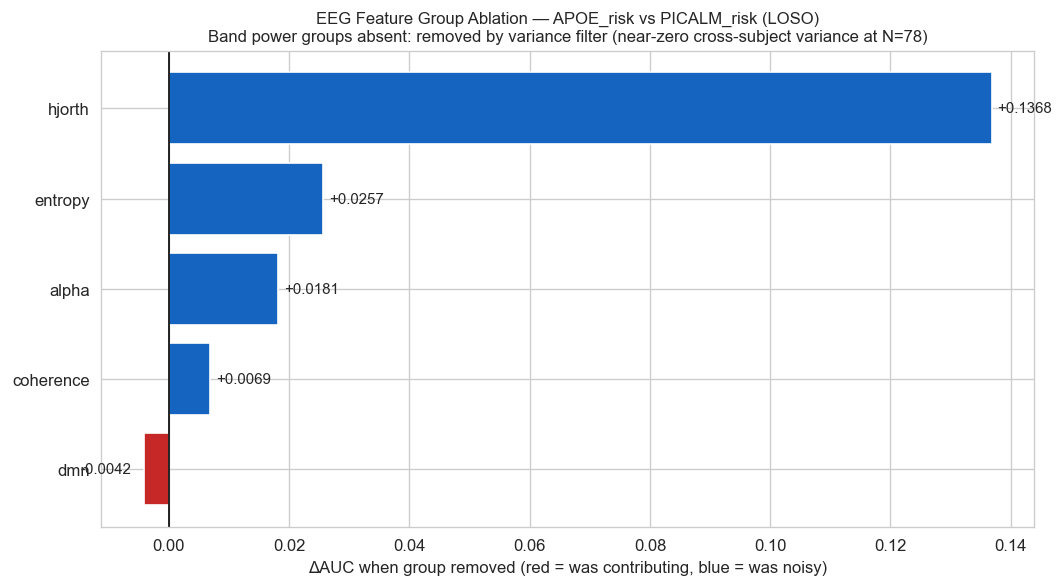

Saved → results/figures/pearl_ablation_bar.png
Most important group: dmn (RQ2 answer)


In [4]:
# Ablation bar chart
abl_plot = ablation_df[(ablation_df["group"]!="ALL (baseline)") & (ablation_df["n_removed"]>0)].copy()
abl_plot = abl_plot.sort_values("delta_auc")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#C62828" if d<0 else "#1565C0" for d in abl_plot["delta_auc"]]
bars = ax.barh(abl_plot["group"], abl_plot["delta_auc"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
for bar, val in zip(bars, abl_plot["delta_auc"]):
    xpos = val-0.002 if val<0 else val+0.001
    ax.text(xpos, bar.get_y()+bar.get_height()/2, f"{val:+.4f}",
            va="center", ha="right" if val<0 else "left", fontsize=9)
ax.set_xlabel("ΔAUC when group removed (red = was contributing, blue = was noisy)")
ax.set_title("EEG Feature Group Ablation — APOE_risk vs PICALM_risk (LOSO)\n"
             "Band power groups absent: removed by variance filter (near-zero cross-subject variance at N=78)", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pearl_ablation_bar.png", bbox_inches="tight")
plt.show()
print("Saved → results/figures/pearl_ablation_bar.png")
print(f"Most important group: {abl_plot.loc[abl_plot['delta_auc'].idxmin(),'group']} (RQ2 answer)")

---
## Part 2 — EEGNet (PEARL-Neuro)

**Architecture:** Lawhern et al. 2018. Depthwise separable convolutions designed specifically for EEG at small N.

In [5]:
class EEGNet(nn.Module):
    """EEGNet — Lawhern et al. 2018 (doi:10.1088/1741-2552/aace8c)."""
    def __init__(self, n_classes, n_channels, n_times, sfreq=500,
                 F1=8, D=2, F2=None, dropout=0.5):
        super().__init__()
        F2 = F2 or F1*D
        temp_kern = (sfreq//2)|1  # odd number, ~half sampling frequency
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1,temp_kern), padding=(0,temp_kern//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_channels,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(), nn.AvgPool2d((1,4)), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1,8)), nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1,1,n_channels,n_times)
            self._flat = self.block2(self.block1(dummy)).view(1,-1).shape[1]
        self.classifier = nn.Linear(self._flat, n_classes)

    def forward_embed(self, x):
        return self.block2(self.block1(x)).view(x.size(0),-1)

    def forward(self, x):
        return self.classifier(self.forward_embed(x))


def augment_epoch(ep):
    ep = ep + np.random.normal(0, 0.05*ep.std(), ep.shape).astype(np.float32)
    ep *= np.random.binomial(1, 0.9, size=ep.shape[0]).astype(np.float32)[:,np.newaxis]
    ep  = np.roll(ep, np.random.randint(0, max(1,ep.shape[1]//4)), axis=1)
    ep *= np.random.uniform(0.8, 1.2)
    return ep


class PreloadedEEGDataset(Dataset):
    def __init__(self, epoch_store, subject_ids, labels,
                 augment=False, max_eps=30):
        self.augment = augment
        self.items   = []
        for sid, lbl in zip(subject_ids, labels):
            sid_int = int(sid)
            if sid_int not in epoch_store: continue
            data = epoch_store[sid_int]
            if max_eps and len(data)>max_eps:
                idx = np.random.choice(len(data), max_eps, replace=False)
                data = data[idx]
            for ep in data:
                self.items.append((ep, int(lbl)))
    def __len__(self):  return len(self.items)
    def __getitem__(self, i):
        ep, lbl = self.items[i]
        if self.augment: ep = augment_epoch(ep.copy())
        return torch.tensor(ep, dtype=torch.float32).unsqueeze(0), torch.tensor(lbl, dtype=torch.long)

print("EEGNet + dataset defined.")

EEGNet + dataset defined.


In [6]:
# Pre-load all .fif files into RAM (saves ~6000 file reads during LOSO)
import mne; mne.set_log_level("WARNING")

print("Pre-loading .fif epoch files...")
t0 = time.time()
epoch_store = {}; n_ch = None; n_t = None; missing = []

load_iter = tqdm_nb(list(zip(df_pearl["subject_id"].values, y)),
                    desc="Loading .fif", unit="subj") if TQDM_OK else zip(df_pearl["subject_id"].values, y)

for sid, lbl in load_iter:
    sid_int = int(sid)
    fif = EPOCHS_DIR / f"sub-{sid_int:02d}_task-rest_clean-epo.fif"
    if not fif.exists(): missing.append(sid_int); continue
    try:
        data = mne.read_epochs(str(fif), preload=True, verbose=False).get_data().astype(np.float32)
        epoch_store[sid_int] = data
        if n_ch is None: n_ch, n_t = data.shape[1], data.shape[2]
    except Exception as e:
        print(f"  WARNING sub-{sid_int:02d}: {e}"); missing.append(sid_int)

total_eps = sum(v.shape[0] for v in epoch_store.values())
print(f"Loaded: {len(epoch_store)}/{len(df_pearl)} subjects ({time.time()-t0:.1f}s)")
print(f"Epochs: {total_eps} total | Shape: {n_ch}ch × {n_t}t")
if missing: print(f"Missing: {missing}")

Pre-loading .fif epoch files...


Loading .fif:   0%|          | 0/78 [00:00<?, ?subj/s]

Loaded: 77/78 subjects (191.2s)
Epochs: 12127 total | Shape: 127ch × 2000t
Missing: [55]


In [6]:
def compute_class_weights(labels):
    classes, counts = np.unique(labels, return_counts=True)
    return torch.tensor(len(labels)/(len(classes)*counts), dtype=torch.float32)

def _run_epoch(model, loader, criterion, optimizer, device, training):
    model.train() if training else model.eval()
    total_loss, preds, probs, lbls = 0.0, [], [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, yb in loader:
            X, yb = X.to(device), yb.to(device)
            logits = model(X)
            loss   = criterion(logits, yb)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            probs.extend(F.softmax(logits,1)[:,1].detach().cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy())
            lbls.extend(yb.cpu().numpy())
    f1 = f1_score(lbls, preds, average="macro", zero_division=0)
    return total_loss/len(loader), f1, np.array(probs), np.array(lbls)

def train_eegnet_fold(fold_idx, train_sids, train_labels, test_sids, test_labels,
                      epoch_store, n_channels, n_times,
                      max_epochs=100, patience=12, lr=1e-3, batch_size=32,
                      dropout=0.5, weight_decay=1e-3, max_eps=30, fold_pbar=None):
    set_all_seeds()
    train_ds = PreloadedEEGDataset(epoch_store, train_sids, train_labels, augment=True, max_eps=max_eps)
    test_ds  = PreloadedEEGDataset(epoch_store, test_sids,  test_labels,  augment=False, max_eps=None)
    if len(train_ds)==0 or len(test_ds)==0: return None

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    model = EEGNet(2, n_channels, n_times, sfreq=500, dropout=dropout).to(DEVICE)
    cw    = compute_class_weights(train_labels).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=cw)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=patience//2, factor=0.5)

    best_f1, no_imp, best_state = -1.0, 0, None
    train_losses, val_f1s = [], []
    ckpt_path = CKPT_DIR / f"eegnet_fold{fold_idx}_best.pt"

    ep_iter = (tqdm_nb(range(max_epochs), desc=f"F{fold_idx}", leave=False, unit="ep")
               if TQDM_OK else range(max_epochs))
    for ep in ep_iter:
        tr_loss, _, _, _ = _run_epoch(model, train_dl, crit, opt, DEVICE, True)
        _,  vf1, vprobs, vlbls = _run_epoch(model, test_dl,  crit, None, DEVICE, False)
        sched.step(vf1); train_losses.append(tr_loss); val_f1s.append(vf1)
        if vf1 > best_f1:
            best_f1 = vf1; no_imp = 0
            best_state = deepcopy(model.state_dict())
        else:
            no_imp += 1
            if no_imp >= patience: break
        if TQDM_OK and ep_iter is not None:
            try: ep_iter.set_postfix({"loss":f"{tr_loss:.3f}","vf1":f"{vf1:.3f}","best":f"{best_f1:.3f}"})
            except: pass

    if best_state: model.load_state_dict(best_state); torch.save(best_state, ckpt_path)

    model.eval()
    _, final_f1, final_probs, final_lbls = _run_epoch(model, test_dl, crit, None, DEVICE, False)
    final_preds = (final_probs >= 0.5).astype(int)
    try: final_auc = roc_auc_score(final_lbls, final_probs)
    except: final_auc = float("nan")

    result = {"fold":fold_idx,"test_sids":list(test_sids),"preds":final_preds.tolist(),
              "probs":final_probs.tolist(),"true_labels":final_lbls.tolist(),
              "final_f1":final_f1,"final_auc":final_auc,"best_val_f1":best_f1,
              "epochs_run":len(train_losses),"train_losses":train_losses,"best_ckpt":str(ckpt_path),
              "n_test_epochs":len(test_ds)}
    if fold_pbar is not None and TQDM_OK:
        try: fold_pbar.set_postfix({"F1":f"{final_f1:.3f}","AUC":f"{final_auc:.3f}","ep":len(train_losses)})
        except: pass
    return result

print("Training utilities defined.")

Training utilities defined.


In [ ]:
set_all_seeds()

MAX_FOLDS = None  # None = all 78 | set to 5 for smoke test

EEGNET_CONFIG = dict(max_epochs=100, patience=12, lr=1e-3,
                     batch_size=32, dropout=0.5, weight_decay=1e-3, max_eps=30)

eegnet_fold_results = []
subject_ids_arr = df_pearl["subject_id"].values
folds_to_run = loso_splits[:MAX_FOLDS] if MAX_FOLDS else loso_splits

print(f"Device: {DEVICE} | Folds: {len(folds_to_run)} | Subjects: {len(epoch_store)}")
t_start = time.time()

fold_bar = tqdm_nb(folds_to_run, desc="LOSO folds", unit="fold") if TQDM_OK else folds_to_run
for split in fold_bar:
    tr, te = split["train_indices"], split["test_indices"]
    res = train_eegnet_fold(
        fold_idx=split["fold"],
        train_sids=subject_ids_arr[tr], train_labels=y[tr],
        test_sids=subject_ids_arr[te],  test_labels=y[te],
        epoch_store=epoch_store, n_channels=n_ch, n_times=n_t,
        fold_pbar=fold_bar if TQDM_OK else None,
        **EEGNET_CONFIG
    )
    if res: eegnet_fold_results.append(res)

total_time = time.time()-t_start
avg_ep = np.mean([r["epochs_run"] for r in eegnet_fold_results])
all_f1s = [r["final_f1"] for r in eegnet_fold_results]
all_aucs = [r["final_auc"] for r in eegnet_fold_results if not np.isnan(r["final_auc"])]
print(f"\nEEGNet LOSO — {len(eegnet_fold_results)} folds in {total_time/60:.1f} min")
print(f"Avg epochs: {avg_ep:.0f} | F1 mean: {np.mean(all_f1s):.4f}±{np.std(all_f1s):.4f}")
print(f"Bimodal: {sum(f==1.0 for f in all_f1s)} perfect | {sum(f<0.51 for f in all_f1s)} chance")

In [ ]:
# Save EEGNet fold results + aggregate metrics
if eegnet_fold_results:
    # Subject-level: one entry per fold (each fold = one test subject in LOSO)
    detail_rows = []
    for r in eegnet_fold_results:
        # Epoch-level AUC undefined for single subject (1 test sample per fold in LOSO)
        detail_rows.append({
            "fold": r["fold"], "F1": r["final_f1"],
            "n_test_epochs": r["n_test_epochs"], "epochs_run": r["epochs_run"],
            "best_val_f1": r["best_val_f1"], "final_auc": r["final_auc"]
        })
    fold_detail_df = pd.DataFrame(detail_rows)
    fold_detail_df.to_csv(RESULTS_DIR / "eegnet_loso_fold_detail.csv", index=False)

    fold_summary_df = fold_detail_df.copy()
    fold_summary_df.columns = [c if c!="F1" else "final_f1" for c in fold_summary_df.columns]
    fold_summary_df.to_csv(RESULTS_DIR / "eegnet_loso_fold_summary.csv", index=False)

    # Epoch-level aggregate metrics
    all_preds  = np.array([p for r in eegnet_fold_results for p in r["preds"]])
    all_probs  = np.array([p for r in eegnet_fold_results for p in r["probs"]])
    all_labels = np.array([l for r in eegnet_fold_results for l in r["true_labels"]])

    ep_auc = roc_auc_score(all_labels, all_probs)
    ep_f1  = f1_score(all_labels, all_preds, average="macro")
    ep_mcc = matthews_corrcoef(all_labels, all_preds)

    # Subject-level: fold F1 per subject (LOSO = each subject is test once)
    subj_f1s = [r["final_f1"] for r in eegnet_fold_results]
    subj_auc = ep_auc  # epoch-level AUC is the canonical metric

    print("="*55)
    print("EEGNet PEARL-Neuro LOSO")
    print("="*55)
    print(f"Epoch-level AUC: {ep_auc:.4f}  F1: {ep_f1:.4f}  MCC: {ep_mcc:.4f}")
    print(f"Bimodal structure: {sum(f==1.0 for f in subj_f1s)} perfect folds / {sum(f<0.51 for f in subj_f1s)} chance folds")
    print(f"e3/e4 detection: see analysis.ipynb Part 0 (APOE subgroup)")

    upsert_result({"model":"EEGNet_epoch_level","dataset":"PEARL-Neuro",
                   "task":"APOE_risk vs PICALM_risk","split":"LOSO","n_features":"raw_epochs",
                   "macro_f1":round(ep_f1,4),"roc_auc":round(ep_auc,4),
                   "accuracy":round(accuracy_score(all_labels,all_preds),4),"mcc":round(ep_mcc,4)})
    
    # ── Subject-level AUC: mean epoch prob per fold → one prob per subject ──
    sl_probs  = np.array([np.mean(r["probs"])      for r in eegnet_fold_results])
    sl_labels = np.array([r["true_labels"][0]      for r in eegnet_fold_results])
    sl_preds  = (sl_probs >= 0.5).astype(int)

    sl_auc = roc_auc_score(sl_labels, sl_probs)
    sl_f1  = f1_score(sl_labels, sl_preds, average="macro")
    sl_mcc = matthews_corrcoef(sl_labels, sl_preds)
    sl_acc = accuracy_score(sl_labels, sl_preds)

    print(f"EEGNet subject-level: AUC={sl_auc:.4f}  F1={sl_f1:.4f}  MCC={sl_mcc:.4f}  Acc={sl_acc:.4f}")
    upsert_result({"model": "EEGNet_subject_level", "dataset": "PEARL-Neuro",
                   "task": "APOE_risk vs PICALM_risk", "split": "LOSO",
                   "n_features": "raw_epochs",
                   "macro_f1": round(sl_f1, 4), "roc_auc": round(sl_auc, 4),
                   "accuracy": round(sl_acc, 4), "mcc": round(sl_mcc, 4)})
    print("Saved → EEGNet_subject_level added to results_table.csv")

    print("Saved → results/eegnet_loso_fold_detail.csv + eegnet_loso_fold_summary.csv")

In [11]:
# EEGNet training curves figure
if eegnet_fold_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    max_len = max(len(r["train_losses"]) for r in eegnet_fold_results)
    loss_mat = np.array([r["train_losses"]+[np.nan]*(max_len-len(r["train_losses"]))
                         for r in eegnet_fold_results])
    m = np.nanmean(loss_mat, 0); s = np.nanstd(loss_mat, 0)
    x = np.arange(1, max_len+1)
    axes[0].plot(x, m, color="#1565C0", label="Mean train loss")
    axes[0].fill_between(x, m-s, m+s, alpha=0.2, color="#1565C0")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CrossEntropy Loss")
    axes[0].set_title("EEGNet Training Loss (mean±std across LOSO folds)")
    axes[0].legend()

    fold_f1s = [r["best_val_f1"] for r in eegnet_fold_results]
    axes[1].hist(fold_f1s, bins=15, color="#BF360C", edgecolor="white", alpha=0.8)
    axes[1].axvline(np.mean(fold_f1s), color="black", linestyle="--",
                    label=f"Mean={np.mean(fold_f1s):.3f}")
    axes[1].set_xlabel("Best Val F1 per fold"); axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution of Best Val F1 — EEGNet LOSO")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eegnet_training_curves.png", bbox_inches="tight")
    plt.show()
    print("Saved → results/figures/eegnet_training_curves.png")

---
## Part 3 — ResNet18 v2 (OASIS-2, axial orientation verified)

**Tensor orientation confirmed:** Dim 2 = axial (verified visually — horizontal cross-section with oval ventricles).
**v1 (dim 0 = sagittal) is superseded and not used.**

Axial slices are most informative for hippocampal atrophy — the primary structural MCI biomarker.

In [12]:
# AXIAL_DIM=2 is the confirmed orientation (visual inspection in tensor_orientation_check.png)
AXIAL_DIM = 2

class VerifiedMRISliceDataset(Dataset):
    """MRI slice dataset with confirmed axial orientation (dim=2).
    Returns [3,H,W] slices (3ch for ResNet18 pretrained weights)."""
    def __init__(self, mri_ids, labels, tensor_dir,
                 n_axial=24, n_coronal=12, n_sagittal=12, augment=False):
        self.slices  = []
        self.augment = augment
        import torchvision.transforms as T
        self.tfm = T.Compose([T.Resize((128,128))])
        for mri_id, lbl in zip(mri_ids, labels):
            pt = tensor_dir / str(mri_id) / "mri_tensor.pt"
            if not pt.exists(): continue
            try:
                vol = torch.load(str(pt), map_location="cpu").squeeze().numpy()
                D, H, W = vol.shape
                def _central(dim_size, n_sl, dim_idx):
                    start = max(0, dim_size//2 - n_sl//2)
                    for i in range(start, min(dim_size, start+n_sl)):
                        if   dim_idx==0: slc = vol[i,:,:]
                        elif dim_idx==1: slc = vol[:,i,:]
                        else:            slc = vol[:,:,i]
                        self.slices.append((slc.astype(np.float32), int(lbl), str(mri_id)))
                _central(W, n_axial,    AXIAL_DIM)   # dim 2 = axial
                _central(H, n_coronal,  1)            # dim 1 = coronal
                _central(D, n_sagittal, 0)            # dim 0 = sagittal
            except Exception as e:
                print(f"  skip {mri_id}: {e}")
    def __len__(self): return len(self.slices)
    def __getitem__(self, i):
        slc, lbl, mid = self.slices[i]
        t = torch.from_numpy(slc).unsqueeze(0)
        t = self.tfm(t).repeat(3,1,1)  # [3,128,128]
        if self.augment:
            if torch.rand(1)<0.5: t = torch.flip(t, [-1])
            t = t + torch.randn_like(t)*0.05
        return t, lbl, mid

def build_resnet18(n_classes=2, pretrained=True, dropout=0.3):
    weights = tv_models.ResNet18_Weights.DEFAULT if pretrained else None
    m = tv_models.resnet18(weights=weights)
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(512, n_classes))
    return m

test_m = build_resnet18(n_classes=2, pretrained=False)
test_o = test_m(torch.zeros(2,3,128,128))
print(f"ResNet18 output shape: {test_o.shape}  params: {sum(p.numel() for p in test_m.parameters() if p.requires_grad):,}")
del test_m, test_o

ResNet18 output shape: torch.Size([2, 2])  params: 11,177,538


In [13]:
def train_resnet_fold(fold_idx, train_ids, train_labels, test_ids, test_labels,
                      tensor_dir, n_epochs=40, lr=5e-5, batch_size=64, dropout=0.3, weight_decay=1e-4):
    set_all_seeds()
    train_ds = VerifiedMRISliceDataset(train_ids, train_labels, tensor_dir, augment=True)
    test_ds  = VerifiedMRISliceDataset(test_ids,  test_labels,  tensor_dir, augment=False)
    if not train_ds or not test_ds: return None

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,  num_workers=0)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

    model = build_resnet18(2, True, dropout).to(DEVICE)
    cw    = compute_class_weights(train_labels).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=cw)
    bb_p  = [p for n,p in model.named_parameters() if "fc" not in n]
    hd_p  = list(model.fc.parameters())
    opt   = torch.optim.AdamW([{"params":bb_p,"lr":lr},{"params":hd_p,"lr":lr*10}],
                               weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-6)

    best_f1, best_ckpt = -1.0, CKPT_DIR / f"resnet18_v2_fold{fold_idx}_best.pt"
    ep_iter = tqdm_nb(range(n_epochs), desc=f"Fold {fold_idx}", leave=True) if TQDM_OK else range(n_epochs)
    for ep in ep_iter:
        model.train()
        ep_loss = 0.0
        for X, yb, _ in train_dl:
            X, yb = X.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(X), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); ep_loss += loss.item()
        sched.step()
        model.eval()
        preds, probs, lbls = [], [], []
        with torch.no_grad():
            for X, yb, _ in test_dl:
                out = model(X.to(DEVICE))
                probs.extend(F.softmax(out,1)[:,1].cpu().numpy())
                preds.extend(out.argmax(1).cpu().numpy())
                lbls.extend(yb.numpy())
        vf1 = f1_score(lbls, preds, average="macro", zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1; torch.save(model.state_dict(), best_ckpt)
        if TQDM_OK:
            try: ep_iter.set_postfix({"loss":f"{ep_loss/len(train_dl):.3f}","vf1":f"{vf1:.3f}","best":f"{best_f1:.3f}"})
            except: pass

    # Final evaluation with best checkpoint
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    model.eval()
    preds, probs, lbls, mids = [], [], [], []
    with torch.no_grad():
        for X, yb, mid in test_dl:
            out = model(X.to(DEVICE))
            probs.extend(F.softmax(out,1)[:,1].cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy()); lbls.extend(yb.numpy()); mids.extend(mid)

    try: auc = roc_auc_score(lbls, probs)
    except: auc = float("nan")
    f1 = f1_score(lbls, preds, average="macro", zero_division=0)
    return {"fold":fold_idx,"preds":preds,"probs":probs,"true_labels":lbls,"mri_ids":mids,
            "best_val_f1":best_f1,"final_auc":auc,"final_f1":f1,"best_ckpt":str(best_ckpt)}

print("ResNet18 training function defined.")

ResNet18 training function defined.


In [ ]:
set_all_seeds()

df_oasis  = pd.read_csv(METADATA_DIR / "oasis2_feature_matrix.csv")
df_binary = df_oasis[df_oasis["label"].isin(["Control","MCI"])].copy().reset_index(drop=True)
df_binary["label_int_bin"] = df_binary["label"].map({"Control":0,"MCI":1})
with open(SPLITS_DIR / "oasis2_kfold_splits.json") as f:
    oasis_splits = json.load(f)
mri_ids_arr    = df_binary["mri_id"].values
labels_bin_arr = df_binary["label_int_bin"].values

RESNET_CONFIG = {"n_epochs":40,"lr":5e-5,"batch_size":64,"dropout":0.3,"weight_decay":1e-4}
resnet_fold_results = []
print(f"ResNet18 v2 (AXIAL_DIM={AXIAL_DIM}) | {DEVICE} | {len(oasis_splits)} folds")
print(f"Config: {RESNET_CONFIG}")

for split in oasis_splits:
    tr, te = split["train_indices"], split["test_indices"]
    print(f"\nFold {split['fold']} — train: {split['train_label_dist']}  test: {split['test_label_dist']}")
    res = train_resnet_fold(split["fold"], mri_ids_arr[tr], labels_bin_arr[tr],
                            mri_ids_arr[te], labels_bin_arr[te], TENSOR_DIR, **RESNET_CONFIG)
    if res: resnet_fold_results.append(res)
print(f"\nCompleted {len(resnet_fold_results)} folds.")

In [ ]:
# ResNet18 aggregate results + threshold optimisation + save
if resnet_fold_results:
    all_preds = np.array([p for r in resnet_fold_results for p in r["preds"]])
    all_probs = np.array([p for r in resnet_fold_results for p in r["probs"]])
    all_labels= np.array([l for r in resnet_fold_results for l in r["true_labels"]])
    all_ids   = [i for r in resnet_fold_results for i in r["mri_ids"]]

    # Subject-level majority vote across slices
    subj = {}
    for mid, pred, prob, lbl in zip(all_ids, all_preds, all_probs, all_labels):
        if mid not in subj: subj[mid]={"preds":[],"probs":[],"label":int(lbl)}
        subj[mid]["preds"].append(int(pred)); subj[mid]["probs"].append(float(prob))
    sp = [round(np.mean(v["preds"])) for v in subj.values()]
    sr = [np.mean(v["probs"])        for v in subj.values()]
    sl = [v["label"]                 for v in subj.values()]

    subj_auc = roc_auc_score(sl, sr)
    subj_f1  = f1_score(sl, sp, average="macro")
    subj_mcc = matthews_corrcoef(sl, sp)
    subj_cm  = confusion_matrix(sl, sp)
    mci_rec  = subj_cm[1,1]/subj_cm[1].sum()

    print(f"ResNet18 v2 (subject-level): AUC={subj_auc:.4f}  F1={subj_f1:.4f}  MCI_recall={mci_rec:.4f}")

    # Threshold optimisation
    y_true_s = np.array(sl); y_prob_s = np.array(sr)
    print("\nThreshold optimisation (maximise MCI recall, ctrl spec ≥ 0.60):")
    best_t, best_rec, best_spec = 0.5, 0.0, 0.0
    for t in np.arange(0.20, 0.65, 0.02):
        prd = (y_prob_s >= t).astype(int)
        cm  = confusion_matrix(y_true_s, prd, labels=[0,1])
        if cm[0].sum()==0 or cm[1].sum()==0: continue
        rec  = cm[1,1]/cm[1].sum(); spec = cm[0,0]/cm[0].sum()
        f1t  = f1_score(y_true_s, prd, average="macro", zero_division=0)
        if spec >= 0.60 and rec > best_rec:
            best_rec = rec; best_spec = spec; best_t = t
        print(f"  t={t:.2f}  MCI_recall={rec:.3f}  ctrl_spec={spec:.3f}  F1={f1t:.3f}")
    print(f"\nOptimal t={best_t:.2f}: MCI_recall={best_rec:.3f}  ctrl_spec={best_spec:.3f}")

    # Save predictions
    pred_rows = [{"mri_id":mid,"true_label":v["label"],
                  "pred_label":round(np.mean(v["preds"])),
                  "prob_mci":round(np.mean(v["probs"]),4)}
                 for mid, v in subj.items()]
    pd.DataFrame(pred_rows).to_csv(RESULTS_DIR / "resnet18_v2_subject_predictions.csv", index=False)

    upsert_result({"model":"ResNet18_v2_verified_orientation","dataset":"OASIS-2",
                   "task":"Control vs MCI","split":"StratifiedKFold_5",
                   "n_features":"CNN_slices_verified",
                   "macro_f1":round(subj_f1,4),"roc_auc":round(subj_auc,4),
                   "accuracy":round(accuracy_score(sl,sp),4),"mcc":round(subj_mcc,4)})
    print("\nSaved → results/resnet18_v2_subject_predictions.csv")

---
## Part 4 — Grad-CAM

**Target layer:** `layer4` (last convolutional block in ResNet18, confirmed as `layer4[1].conv2`).
**Note:** Runs on CPU — slow but correct. Uses v2 checkpoints (axial orientation).

In [ ]:
class GradCAM:
    """Selvaraju et al. 2017 — gradient-weighted class activation mapping."""
    def __init__(self, model, target_layer):
        self.model = model; self.activations = None; self.gradients = None; self._hooks = []
        self._hooks.append(target_layer.register_forward_hook(
            lambda m,i,o: setattr(self, "activations", o.detach())))
        self._hooks.append(target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self, "gradients", go[0].detach())))

    def __call__(self, x, class_idx=None):
        self.model.eval(); x = x.clone().requires_grad_(True)
        logits = self.model(x)
        if class_idx is None: class_idx = logits.argmax(1).item()
        self.model.zero_grad(); logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((weights*self.activations).sum(1, keepdim=True)).squeeze().cpu().numpy()
        if cam.max()>0: cam /= cam.max()
        from scipy.ndimage import zoom
        H, W = x.shape[2], x.shape[3]
        cam = zoom(cam, (H/cam.shape[0], W/cam.shape[1]), order=1)
        return cam

    def remove_hooks(self):
        for h in self._hooks: h.remove()

print("GradCAM defined.")

In [ ]:
if resnet_fold_results:
    best_fold = max(resnet_fold_results, key=lambda r: r["best_val_f1"])
    fold_idx  = best_fold["fold"]
    ckpt_path = Path(best_fold["best_ckpt"])
    split_info = oasis_splits[fold_idx]
    print(f"Grad-CAM on fold {fold_idx} (best val F1={best_fold['best_val_f1']:.4f})")
    print(f"Running on {DEVICE} (CPU is slow but correct — ~1-3 min)")

    cam_model = build_resnet18(2, False).to(DEVICE)
    cam_model.load_state_dict(torch.load(str(ckpt_path), map_location=DEVICE))
    cam_model.eval()

    # Target: last conv layer in layer4 (layer4[1].conv2 confirmed by architecture)
    target_layer = cam_model.layer4[1].conv2
    grad_cam = GradCAM(cam_model, target_layer)

    te_ids  = mri_ids_arr[split_info["test_indices"]]
    te_lbls = labels_bin_arr[split_info["test_indices"]]
    test_ds_cam = VerifiedMRISliceDataset(te_ids, te_lbls, TENSOR_DIR,
                                           n_axial=5, n_coronal=0, n_sagittal=0, augment=False)
    class_names = ["Control","MCI"]
    examples = {0:[], 1:[]}
    for i in range(len(test_ds_cam)):
        slc, lbl, _ = test_ds_cam[i]
        if len(examples[lbl]) < 2: examples[lbl].append((slc, lbl))
        if all(len(v)>=2 for v in examples.values()): break

    all_ex = examples[0] + examples[1]
    fig, axes = plt.subplots(len(all_ex), 3, figsize=(10, 3.5*len(all_ex)))
    if len(all_ex)==1: axes = axes[np.newaxis,:]
    for ri, (slc, true_lbl) in enumerate(all_ex):
        x_in = slc.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = cam_model(x_in)
            pred_lbl = logits.argmax(1).item()
            prob = F.softmax(logits,1)[0,1].item()
        cam = grad_cam(x_in, class_idx=pred_lbl)
        slc_np = slc[0].numpy()  # first channel (all 3 are identical)
        axes[ri,0].imshow(slc_np, cmap="gray", origin="lower")
        axes[ri,0].set_title(f"MRI (axial) | True: {class_names[true_lbl]}", fontsize=9)
        axes[ri,1].imshow(slc_np, cmap="gray", origin="lower")
        axes[ri,1].imshow(cam, cmap="jet", alpha=0.5, origin="lower")
        axes[ri,1].set_title(f"Grad-CAM | Pred: {class_names[pred_lbl]} P={prob:.2f}", fontsize=9)
        axes[ri,2].imshow(cam, cmap="hot", origin="lower")
        axes[ri,2].set_title("Activation map", fontsize=9)
        for a in axes[ri]: a.axis("off")
    plt.suptitle("Grad-CAM — ResNet18 v2 (OASIS-2, axial slices, dim=2)\n"
                 "Target layer: layer4[1].conv2 (last conv in ResNet18)", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "resnet18_gradcam.png", bbox_inches="tight")
    plt.show()
    grad_cam.remove_hooks()
    print("Saved → results/figures/resnet18_gradcam.png")
else:
    print("No ResNet results — run Part 3 first.")

---
## Part 5 — Results Comparison Table + model_comparison_auc.png

In [ ]:
# model_comparison_auc.png — Fix 3 from corrections.ipynb absorbed here natively
if results_table_path.exists():
    rt = pd.read_csv(results_table_path)

    # Remove any stale v1 ResNet row (model was ResNet18_subject_level if it appears)
    rt = rt[rt["model"]!="ResNet18_subject_level"].copy().reset_index(drop=True)
    rt.to_csv(results_table_path, index=False)

    print("="*80); print("FULL RESULTS TABLE"); print("="*80)
    for ds in ["PEARL-Neuro","OASIS-2"]:
        sub = rt[rt["dataset"]==ds].copy()
        if sub.empty: continue
        print(f"\n--- {ds} ---")
        cols = ["model","n_features","macro_f1","roc_auc","accuracy","mcc"]
        cols = [c for c in cols if c in sub.columns]
        print(sub[cols].sort_values("roc_auc",ascending=False).to_string(index=False))

    # Model comparison figure (v2 ResNet only — v1 is gone)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, dataset, cmap_name in [(axes[0],"PEARL-Neuro","Blues"),(axes[1],"OASIS-2","Greens")]:
        sub = rt[(rt["dataset"]==dataset) & rt["roc_auc"].notna()].sort_values("roc_auc")
        if sub.empty: ax.set_visible(False); continue
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(0.4+0.5*i/max(1,len(sub)-1)) for i in range(len(sub))]
        bars = ax.barh(sub["model"], sub["roc_auc"], color=colors, edgecolor="white")
        for bar, val in zip(bars, sub["roc_auc"]):
            ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
        ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="Chance")
        ax.set_xlim(0, 1.05); ax.set_xlabel("ROC-AUC")
        ax.set_title(dataset, fontsize=11); ax.legend(fontsize=8)
    plt.suptitle("Model Comparison — ROC-AUC (ResNet18 v2, axial-verified)", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_comparison_auc.png", bbox_inches="tight")
    plt.show()
    print("Saved → results/figures/model_comparison_auc.png")
    print("\nBenchmark context (different tasks — indicative only):")
    print("  Cassani 2018: ~85-90% Acc, AD vs HC | Ieracitano 2019: ~88% Acc, AD vs HC")
    print("  Wen 2020: ~90%+ MRI ResNet on ADNI | No prior APOE vs PICALM EEG benchmark")